In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from scipy import stats
import scipy.stats as sps
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import gaussian_kde
import warnings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

[1-2] ЗАГРУЗКА ДАННЫХ И СТАТИСТИКА

In [ ]:
def load_and_analyze_data():
    """Загрузка данных и базовый анализ"""
    # Загрузка датасета Iris
    iris = datasets.load_iris()
    df = pd.DataFrame(iris.data, columns=iris.feature_names)
    df['target'] = iris.target
    df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
    
    # Правильные названия признаков (как в sklearn)
    selected_features = ['sepal length ()', 'sepal width ()', 
                        'petal length ()', 'petal width ()']
    
    # Создание отфильтрованного датасета
    df_filtered = df[selected_features + ['species']].dropna()
    
    # Вывод статистики
    print("=" * 60)
    print("СТАТИСТИКА ДАТАСЕТА IRIS")
    print("=" * 60)
    print(f"Размерность исходного датасета: {df.shape}")
    print(f"Размерность отфильтрованного датасета: {df_filtered.shape}")
    print(f"Количество признаков: {len(selected_features)}")
    print(f"Количество классов: {len(df_filtered['species'].unique())}")
    
    print("\nРаспределение по классам:")
    class_counts = df_filtered['species'].value_counts()
    for species, count in class_counts.items():
        print(f" - {species}: {count} объектов")
    
    null_count = df.isnull().sum().sum()
    null_percentage = (null_count / df.size * 100)
    print(f"\nПропущенные значения: {null_count} ({null_percentage:.2f}%)")
    print(f"Удалено объектов при фильтрации: {len(df) - len(df_filtered)}")
    
    print("\nОсновные статистики отфильтрованного датасета:")
    # Используем to_string() для полного вывода без обрезки
    stats_table = df_filtered[selected_features].describe()
    print(stats_table.to_string())
    
    return df_filtered, selected_features

# Загрузка и анализ данных
df, features = load_and_analyze_data()
classes = df['species'].unique()

СТАТИСТИКА ДАТАСЕТА IRIS
Размерность исходного датасета: (150, 6)
Размерность отфильтрованного датасета: (150, 5)
Количество признаков: 4
Количество классов: 3

Распределение по классам:
 - setosa: 50 объектов
 - versicolor: 50 объектов
 - virginica: 50 объектов

Пропущенные значения: 0 (0.00%)
Удалено объектов при фильтрации: 0

Основные статистики отфильтрованного датасета:
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count         150.000000        150.000000         150.000000        150.000000
mean            5.843333          3.057333           3.758000          1.199333
std             0.828066          0.435866           1.765298          0.762238
min             4.300000          2.000000           1.000000          0.100000
25%             5.100000          2.800000           1.600000          0.300000
50%             5.800000          3.000000           4.350000          1.300000
75%             6.400000          3.300000           5.100000

[3] ВИЗУАЛИЗАЦИЯ ДАТАСЕТА

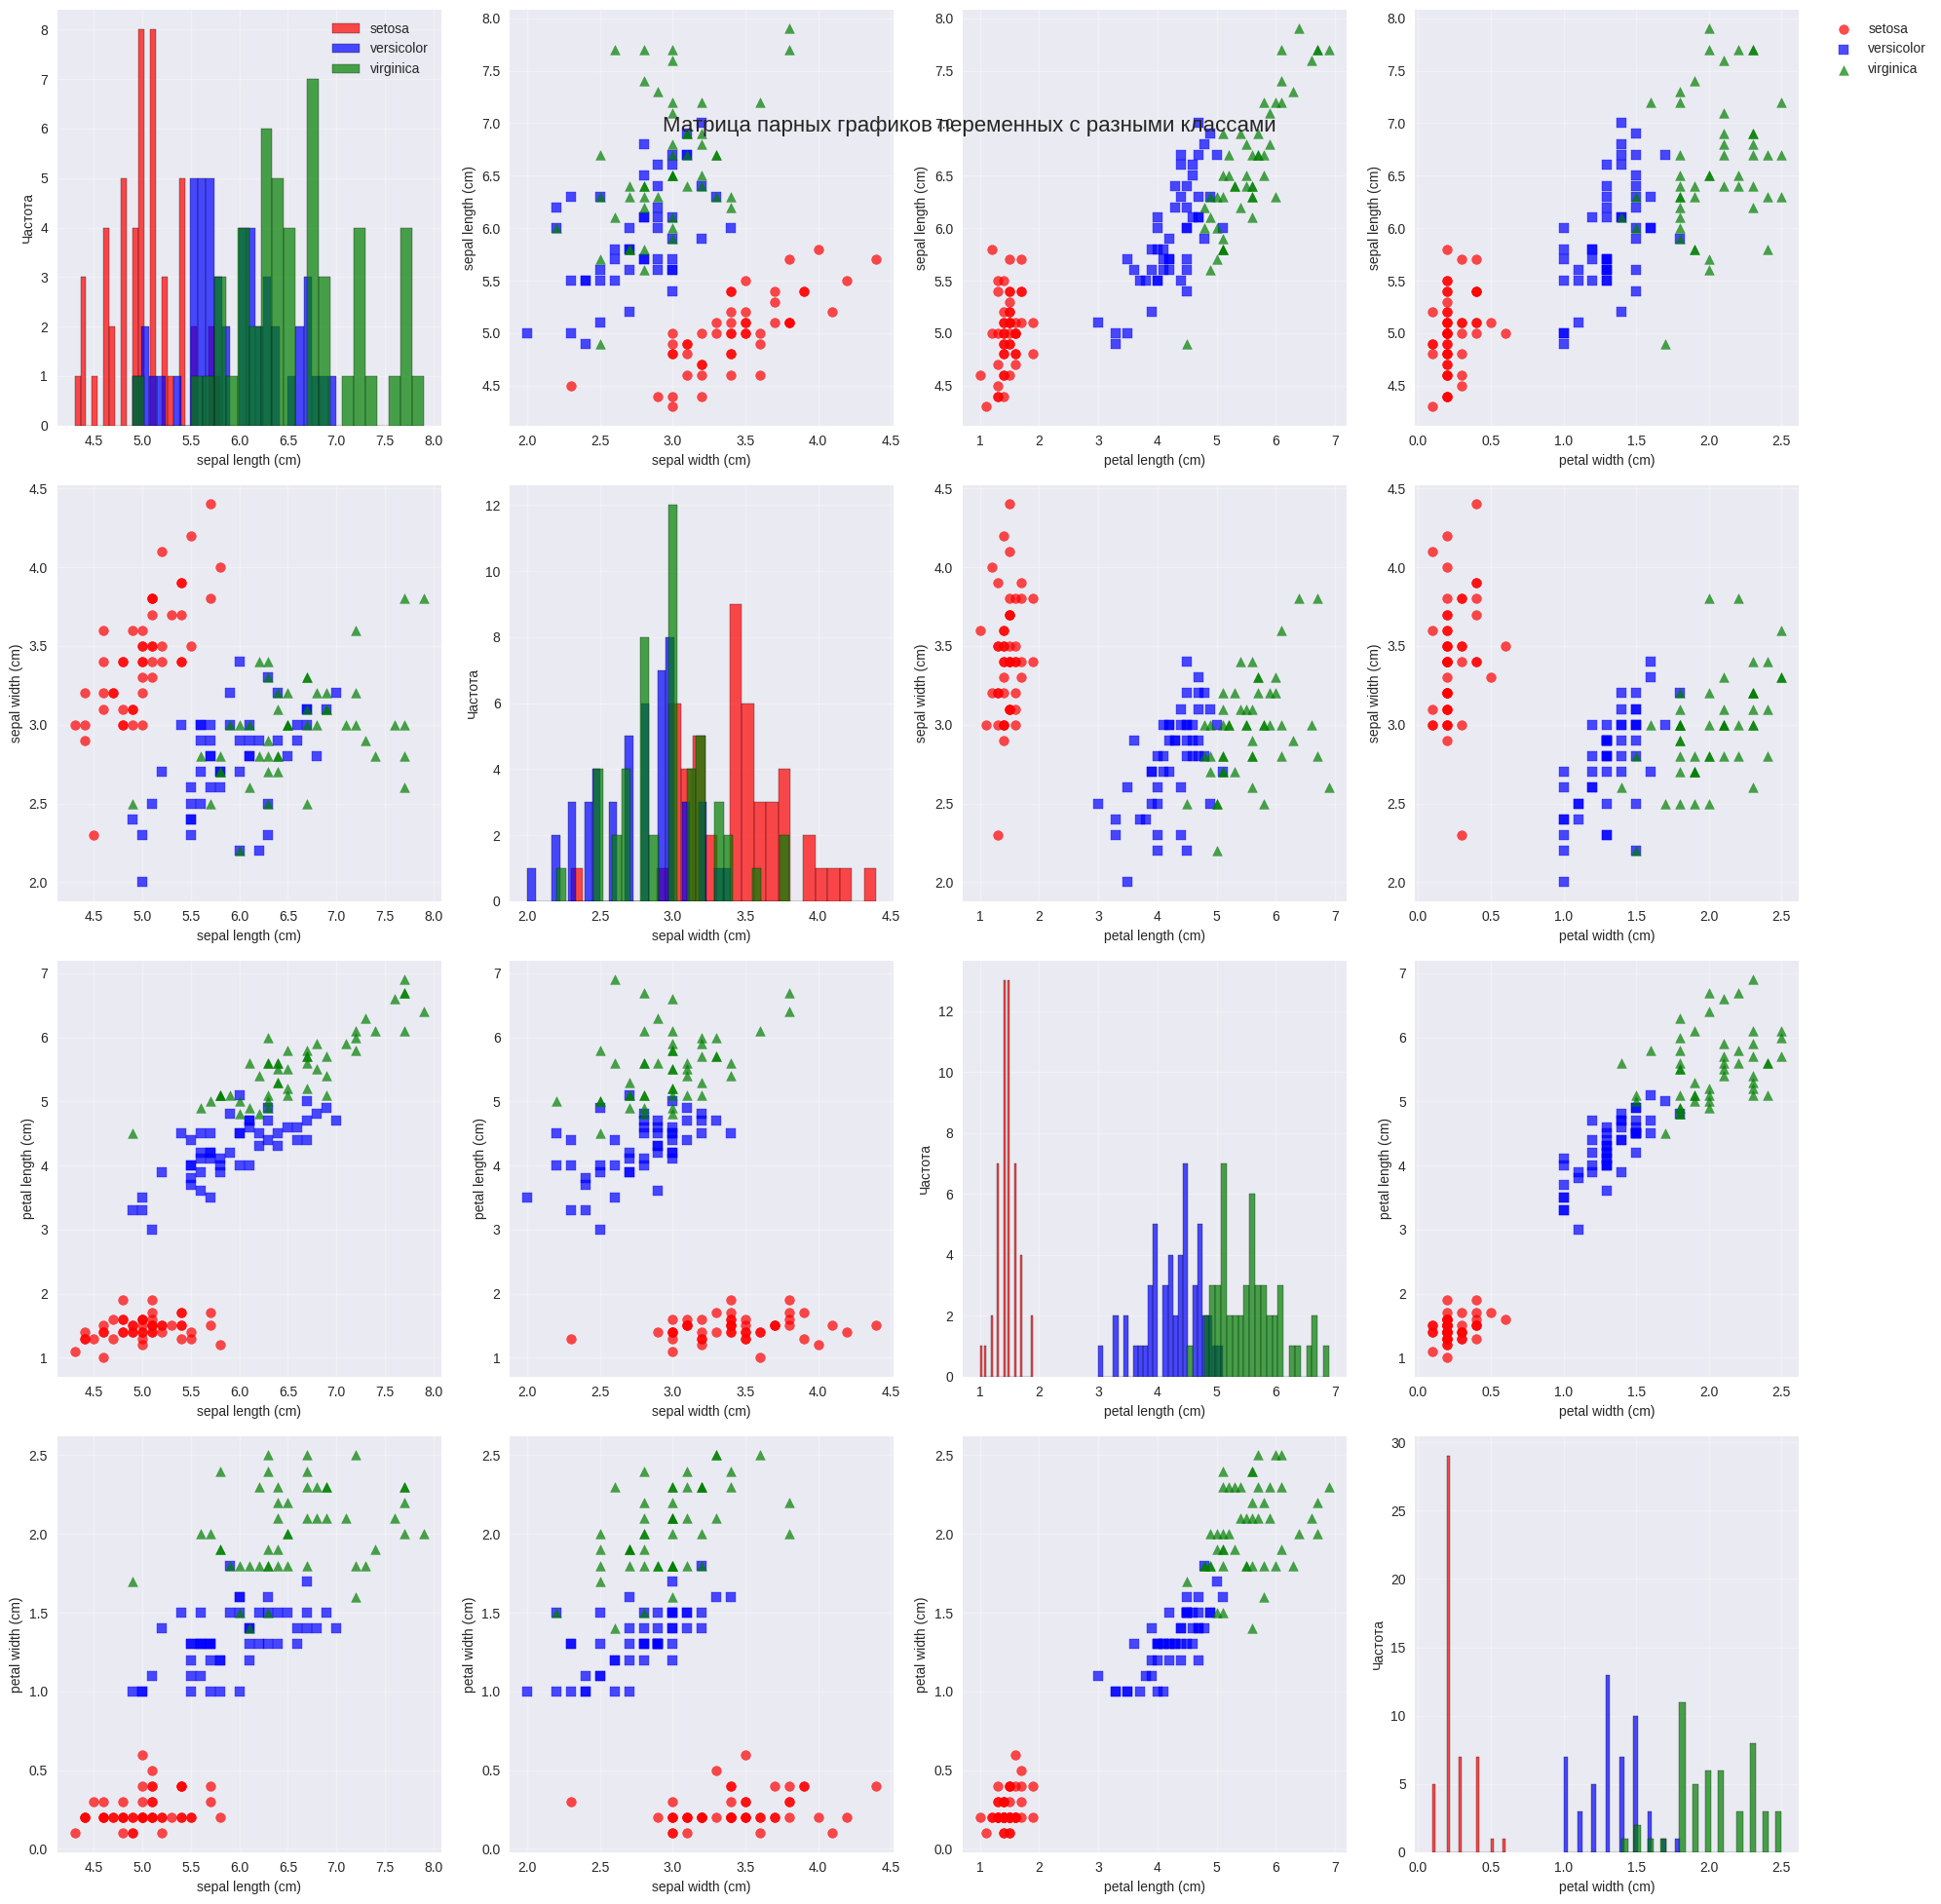

In [27]:
def create_pair_plots(df, features, classes):
    """Создание парных графиков рассеяния и гистограмм"""
    # Настройки визуализации
    class_markers = {'setosa': 'o', 'versicolor': 's', 'virginica': '^'}
    class_colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}
    
    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    fig.suptitle('Матрица парных графиков переменных с разными классами', fontsize=16, y=0.92)
    
    for i, feat1 in enumerate(features):
        for j, feat2 in enumerate(features):
            ax = axes[i, j]
            
            if i != j:
                # График рассеяния для пар переменных
                for class_name in classes:
                    class_data = df[df['species'] == class_name]
                    ax.scatter(class_data[feat2], class_data[feat1], 
                              marker=class_markers[class_name], 
                              color=class_colors[class_name],
                              alpha=0.7, label=class_name, s=50)
                
                ax.set_xlabel(feat2, fontsize=10)
                ax.set_ylabel(feat1, fontsize=10)
                ax.grid(True, alpha=0.3)
                
                if i == 0 and j == len(features)-1:
                    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            else:
                # Гистограмма для одной переменной
                for class_name in classes:
                    class_data = df[df['species'] == class_name]
                    ax.hist(class_data[feat1], bins=25, alpha=0.7, 
                           label=class_name, color=class_colors[class_name],
                           edgecolor='black')
                
                ax.set_xlabel(feat1, fontsize=10)
                ax.set_ylabel('Частота', fontsize=10)
                ax.grid(True, alpha=0.3)
                
                if i == 0 and j == 0:
                    ax.legend()
    
    plt.tight_layout()
    plt.savefig('pair_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

create_pair_plots(df, features, classes)

[4] КОРРЕЛЯЦИОННЫЙ АНАЛИЗ

КОРРЕЛЯЦИИ ДЛЯ ВСЕГО ДАТАСЕТА
Корреляция Пирсона:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
sepal length (cm)           1.000000         -0.117570           0.871754          0.817941
sepal width (cm)           -0.117570          1.000000          -0.428440         -0.366126
petal length (cm)           0.871754         -0.428440           1.000000          0.962865
petal width (cm)            0.817941         -0.366126           0.962865          1.000000

P-значения Пирсона:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
sepal length (cm)       0.000000e+00      1.518983e-01       1.038667e-47      2.325498e-37
sepal width (cm)        1.518983e-01      0.000000e+00       4.513314e-08      4.073229e-06
petal length (cm)       1.038667e-47      4.513314e-08       0.000000e+00      4.675004e-86
petal width (cm)        2.325498e-37      4.073229e-06       4.675004e-86      0.000000e+00


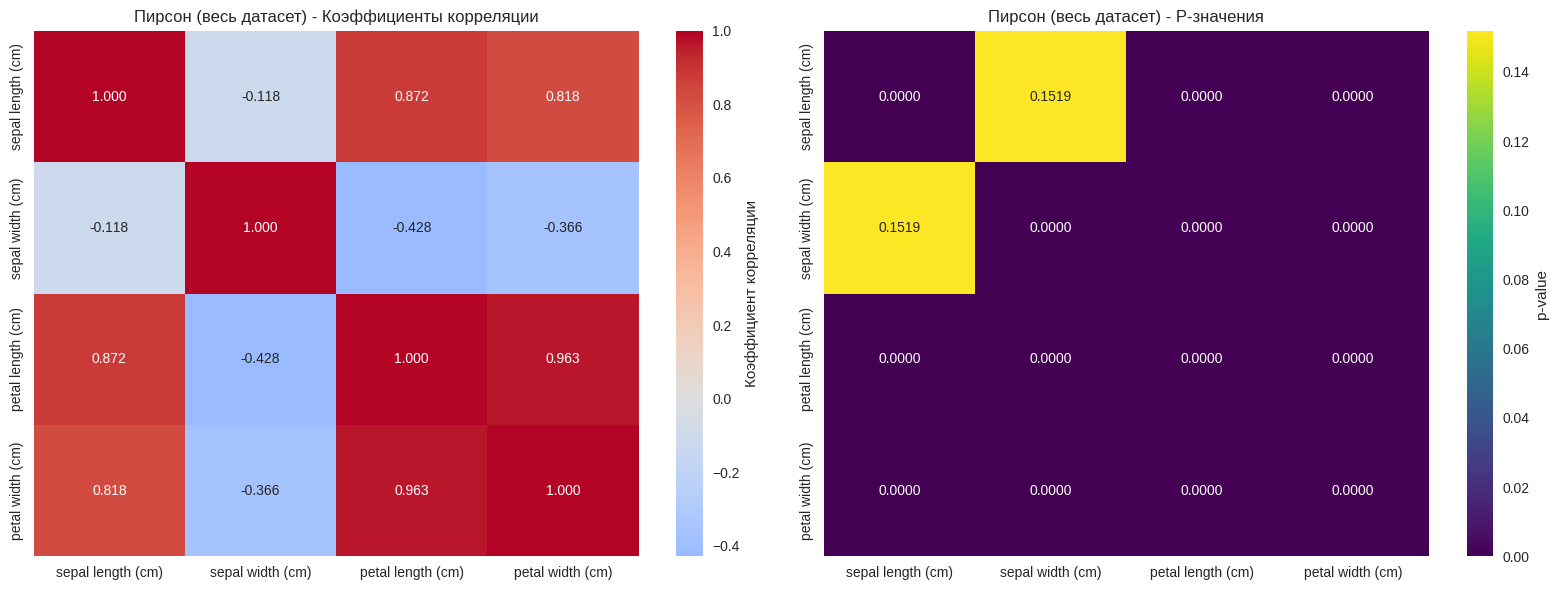

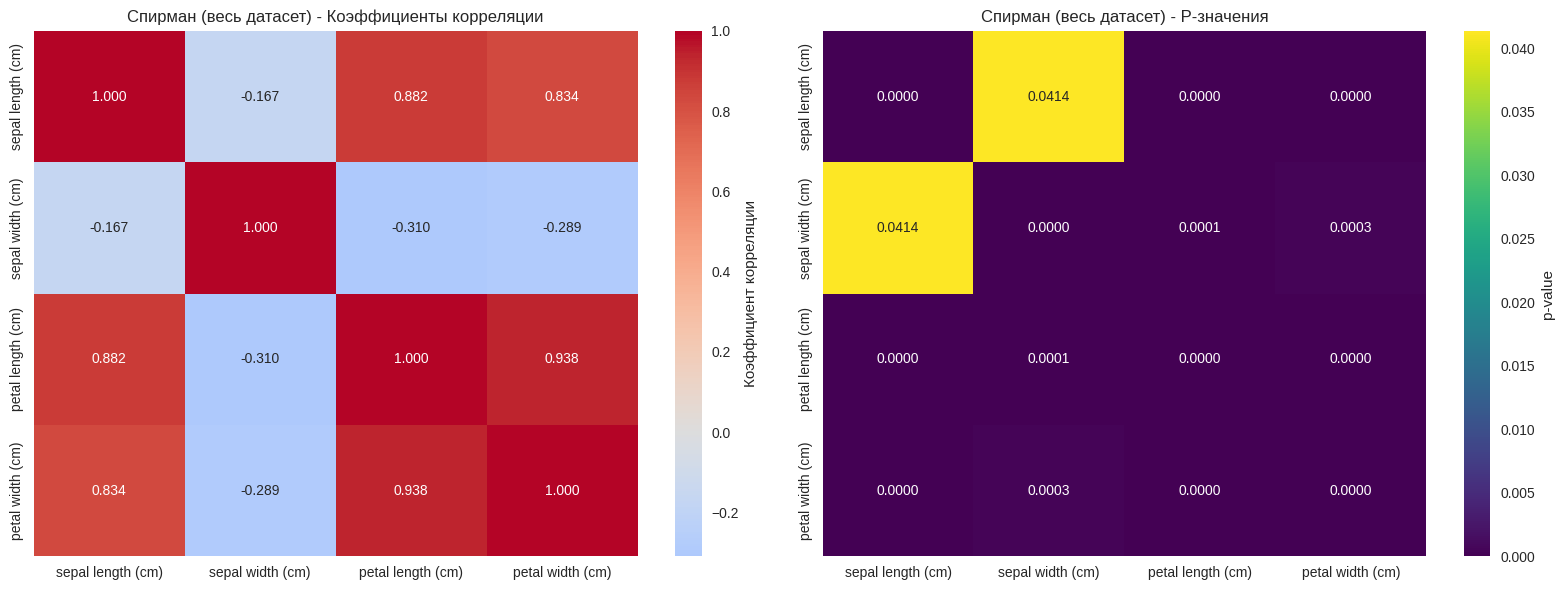


КОРРЕЛЯЦИИ ПО КЛАССАМ

SETOSA:
Корреляция Пирсона:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
sepal length (cm)           1.000000          0.742547           0.267176          0.278098
sepal width (cm)            0.742547          1.000000           0.177700          0.232752
petal length (cm)           0.267176          0.177700           1.000000          0.331630
petal width (cm)            0.278098          0.232752           0.331630          1.000000


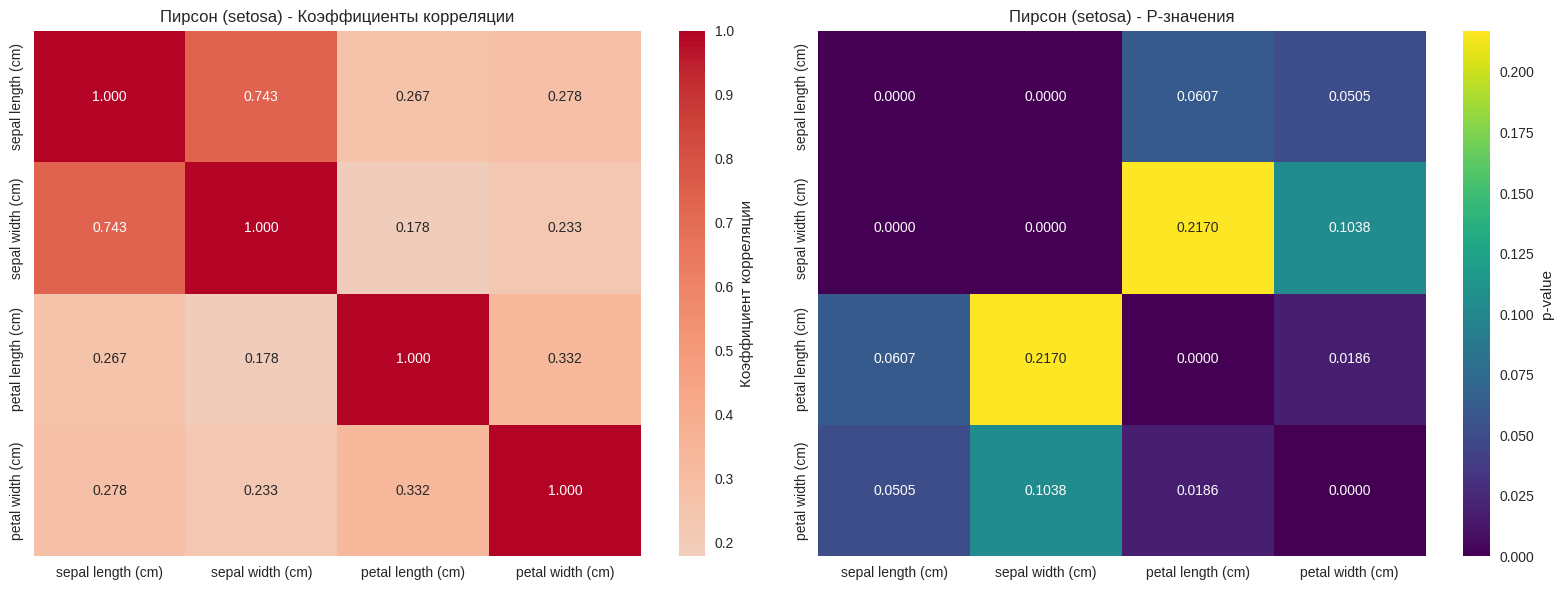

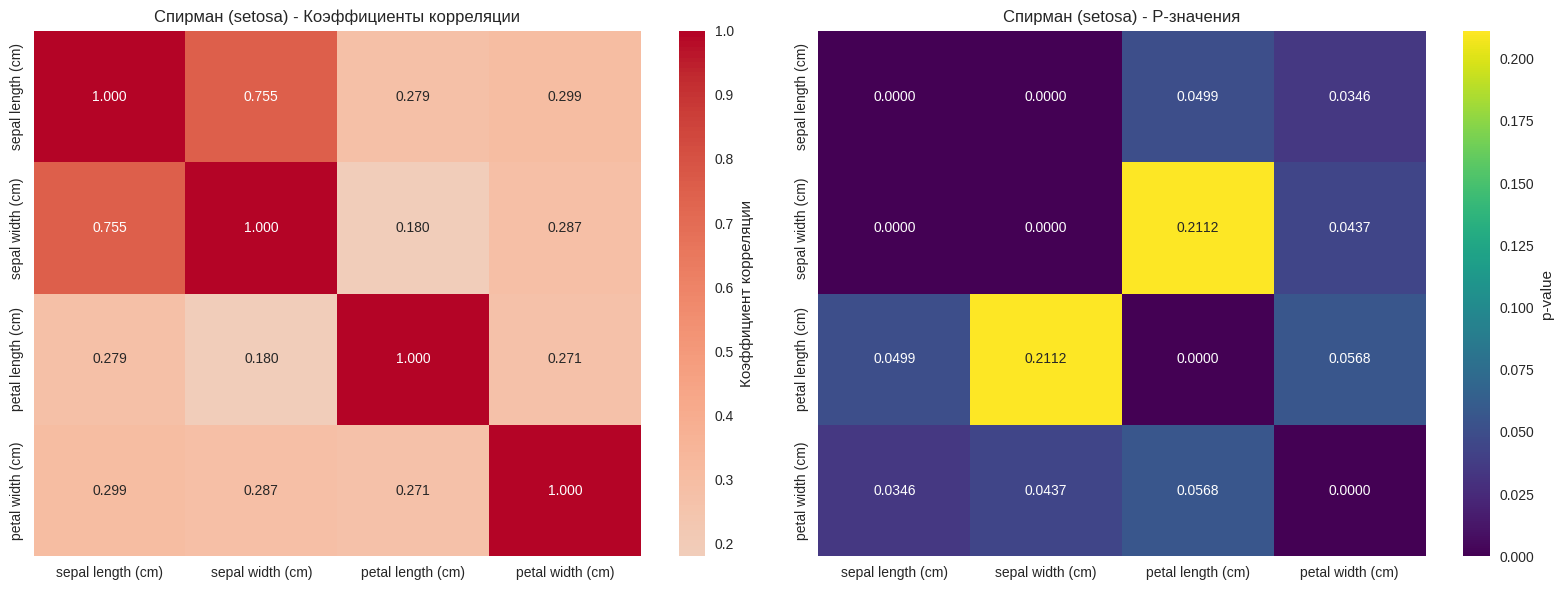


VERSICOLOR:
Корреляция Пирсона:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
sepal length (cm)           1.000000          0.525911           0.754049          0.546461
sepal width (cm)            0.525911          1.000000           0.560522          0.663999
petal length (cm)           0.754049          0.560522           1.000000          0.786668
petal width (cm)            0.546461          0.663999           0.786668          1.000000


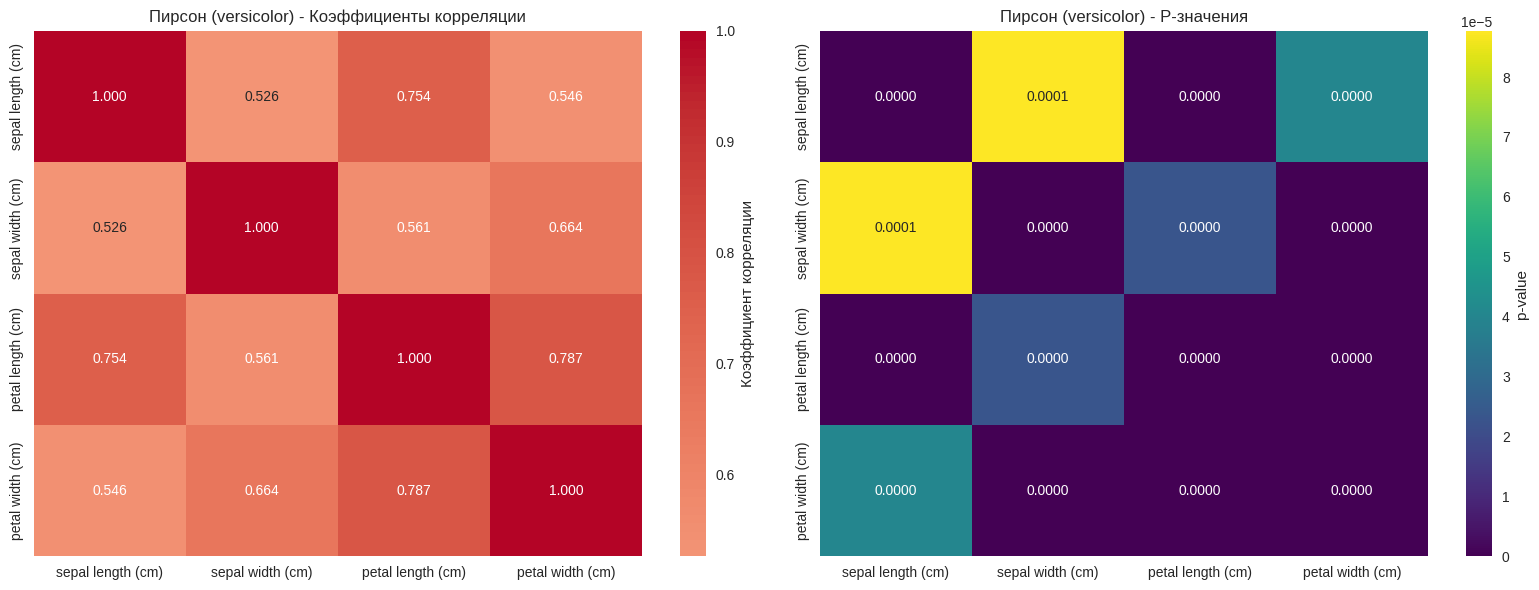

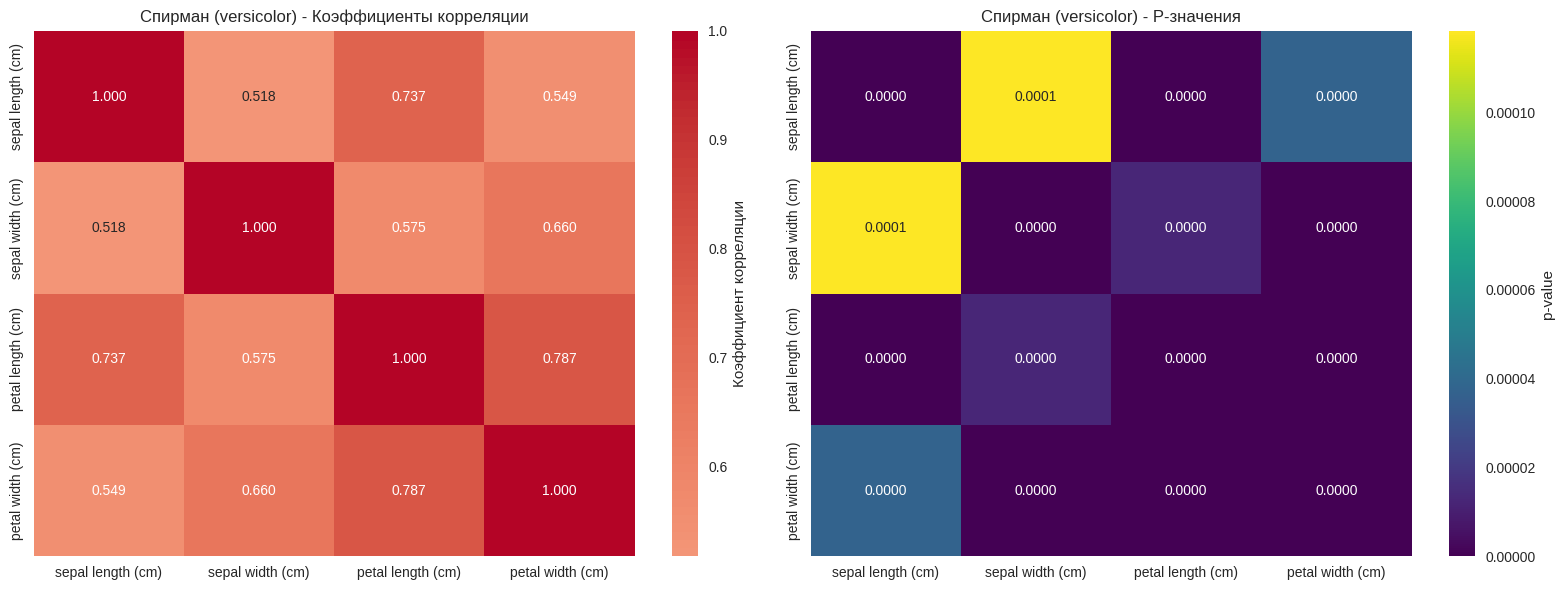


VIRGINICA:
Корреляция Пирсона:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
sepal length (cm)           1.000000          0.457228           0.864225          0.281108
sepal width (cm)            0.457228          1.000000           0.401045          0.537728
petal length (cm)           0.864225          0.401045           1.000000          0.322108
petal width (cm)            0.281108          0.537728           0.322108          1.000000


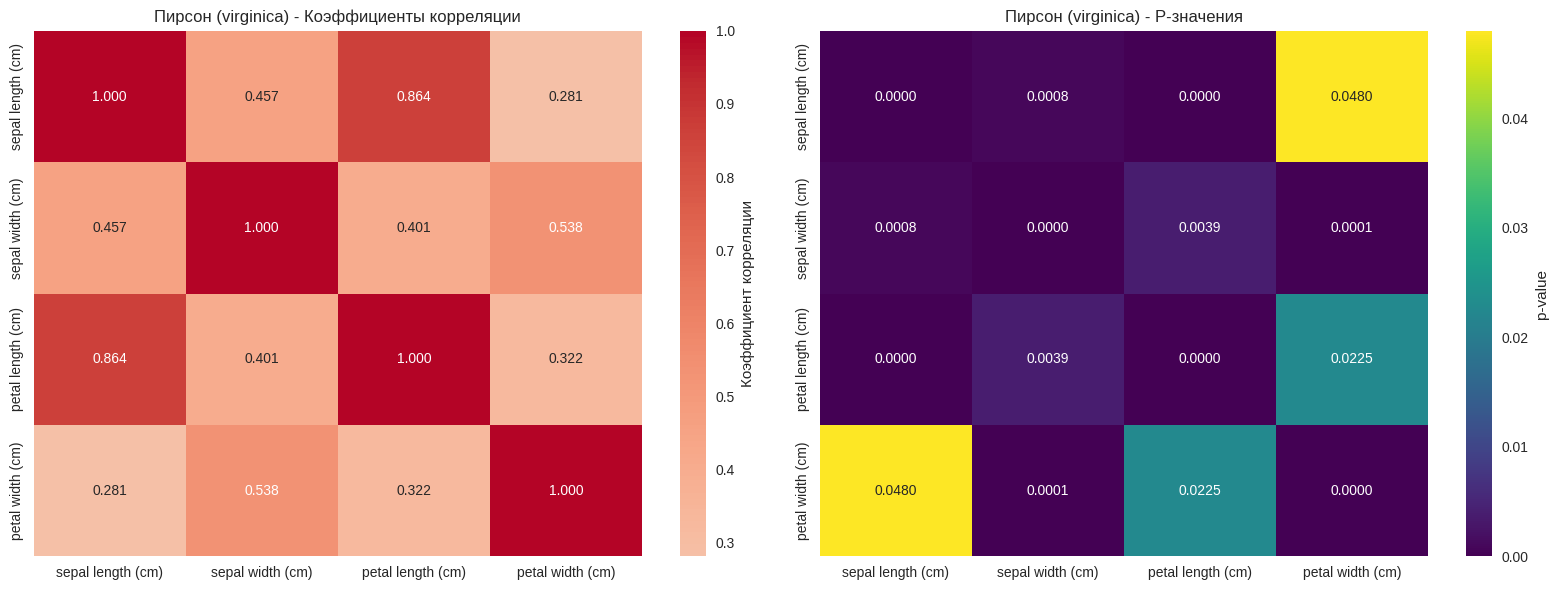

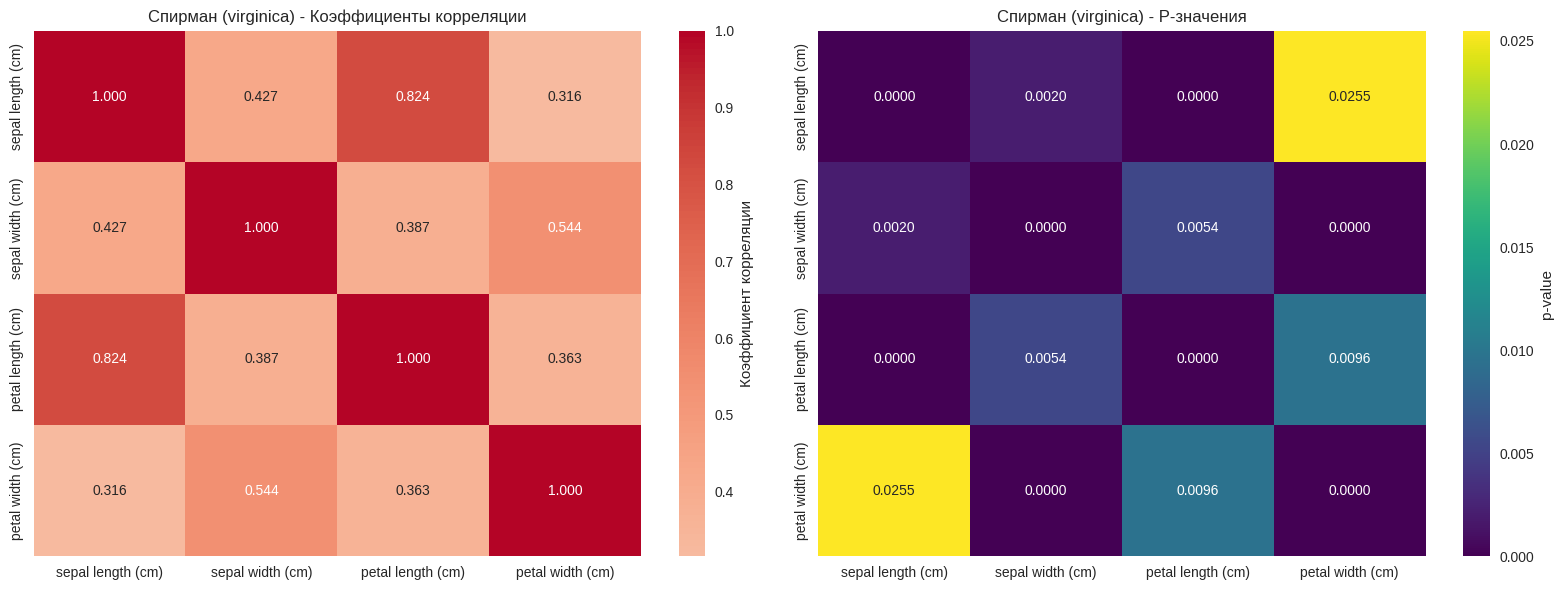

In [ ]:
def calculate_correlations(data, features, method='pearson'):
    """Расчет корреляций с p-значениями"""
    corr_matrix = np.zeros((len(features), len(features)))
    p_matrix = np.zeros((len(features), len(features)))
    
    for i, feat1 in enumerate(features):
        for j, feat2 in enumerate(features):
            if method == 'pearson':
                corr, p_value = stats.pearsonr(data[feat1], data[feat2])
            else:  # spearman
                corr, p_value = stats.spearmanr(data[feat1], data[feat2])
            
            corr_matrix[i, j] = corr
            p_matrix[i, j] = p_value
    
    return pd.DataFrame(corr_matrix, index=features, columns=features), \
           pd.DataFrame(p_matrix, index=features, columns=features)

def plot_correlation_heatmaps(corr_matrix, p_matrix, title):
    """Построение тепловых карт корреляций"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Карта корреляций
    sns.heatmap(corr_matrix, annot=True, ap='coolwarm', center=0, 
                ax=ax1, fmt='.3f', cbar_kws={'label': 'Коэффициент корреляции'})
    ax1.set_title(f'{title} - Коэффициенты корреляции')
    
    # Карта p-значений
    sns.heatmap(p_matrix, annot=True, ap='viridis', 
                ax=ax2, fmt='.4f', cbar_kws={'label': 'p-value'})
    ax2.set_title(f'{title} - P-значения')
    
    plt.tight_layout()
    plt.show()

# Корреляции для всего датасета
print("КОРРЕЛЯЦИИ ДЛЯ ВСЕГО ДАТАСЕТА")
print("=" * 50)

pearson_corr, pearson_p = calculate_correlations(df, features, 'pearson')
spearman_corr, spearman_p = calculate_correlations(df, features, 'spearman')

print("Корреляция Пирсона:")
print(pearson_corr.to_string())
print("\nP-значения Пирсона:")
print(pearson_p.to_string())

plot_correlation_heatmaps(pearson_corr, pearson_p, 'Пирсон (весь датасет)')
plot_correlation_heatmaps(spearman_corr, spearman_p, 'Спирман (весь датасет)')

# Корреляции для каждого класса
print("\n" + "="*60)
print("КОРРЕЛЯЦИИ ПО КЛАССАМ")
print("="*60)

for class_name in classes:
    class_data = df[df['species'] == class_name]
    
    pearson_class, pearson_p_class = calculate_correlations(class_data, features, 'pearson')
    spearman_class, spearman_p_class = calculate_correlations(class_data, features, 'spearman')
    
    print(f"\n{class_name.upper()}:")
    print("Корреляция Пирсона:")
    print(pearson_class.to_string())
    
    plot_correlation_heatmaps(pearson_class, pearson_p_class, f'Пирсон ({class_name})')
    plot_correlation_heatmaps(spearman_class, spearman_p_class, f'Спирман ({class_name})')

[5-6] ЛИНЕЙНАЯ РЕГРЕССИЯ С ИНТЕРВАЛАМИ

РЕГРЕССИЯ С ПРОГНОЗНЫМИ ИНТЕРВАЛАМИ


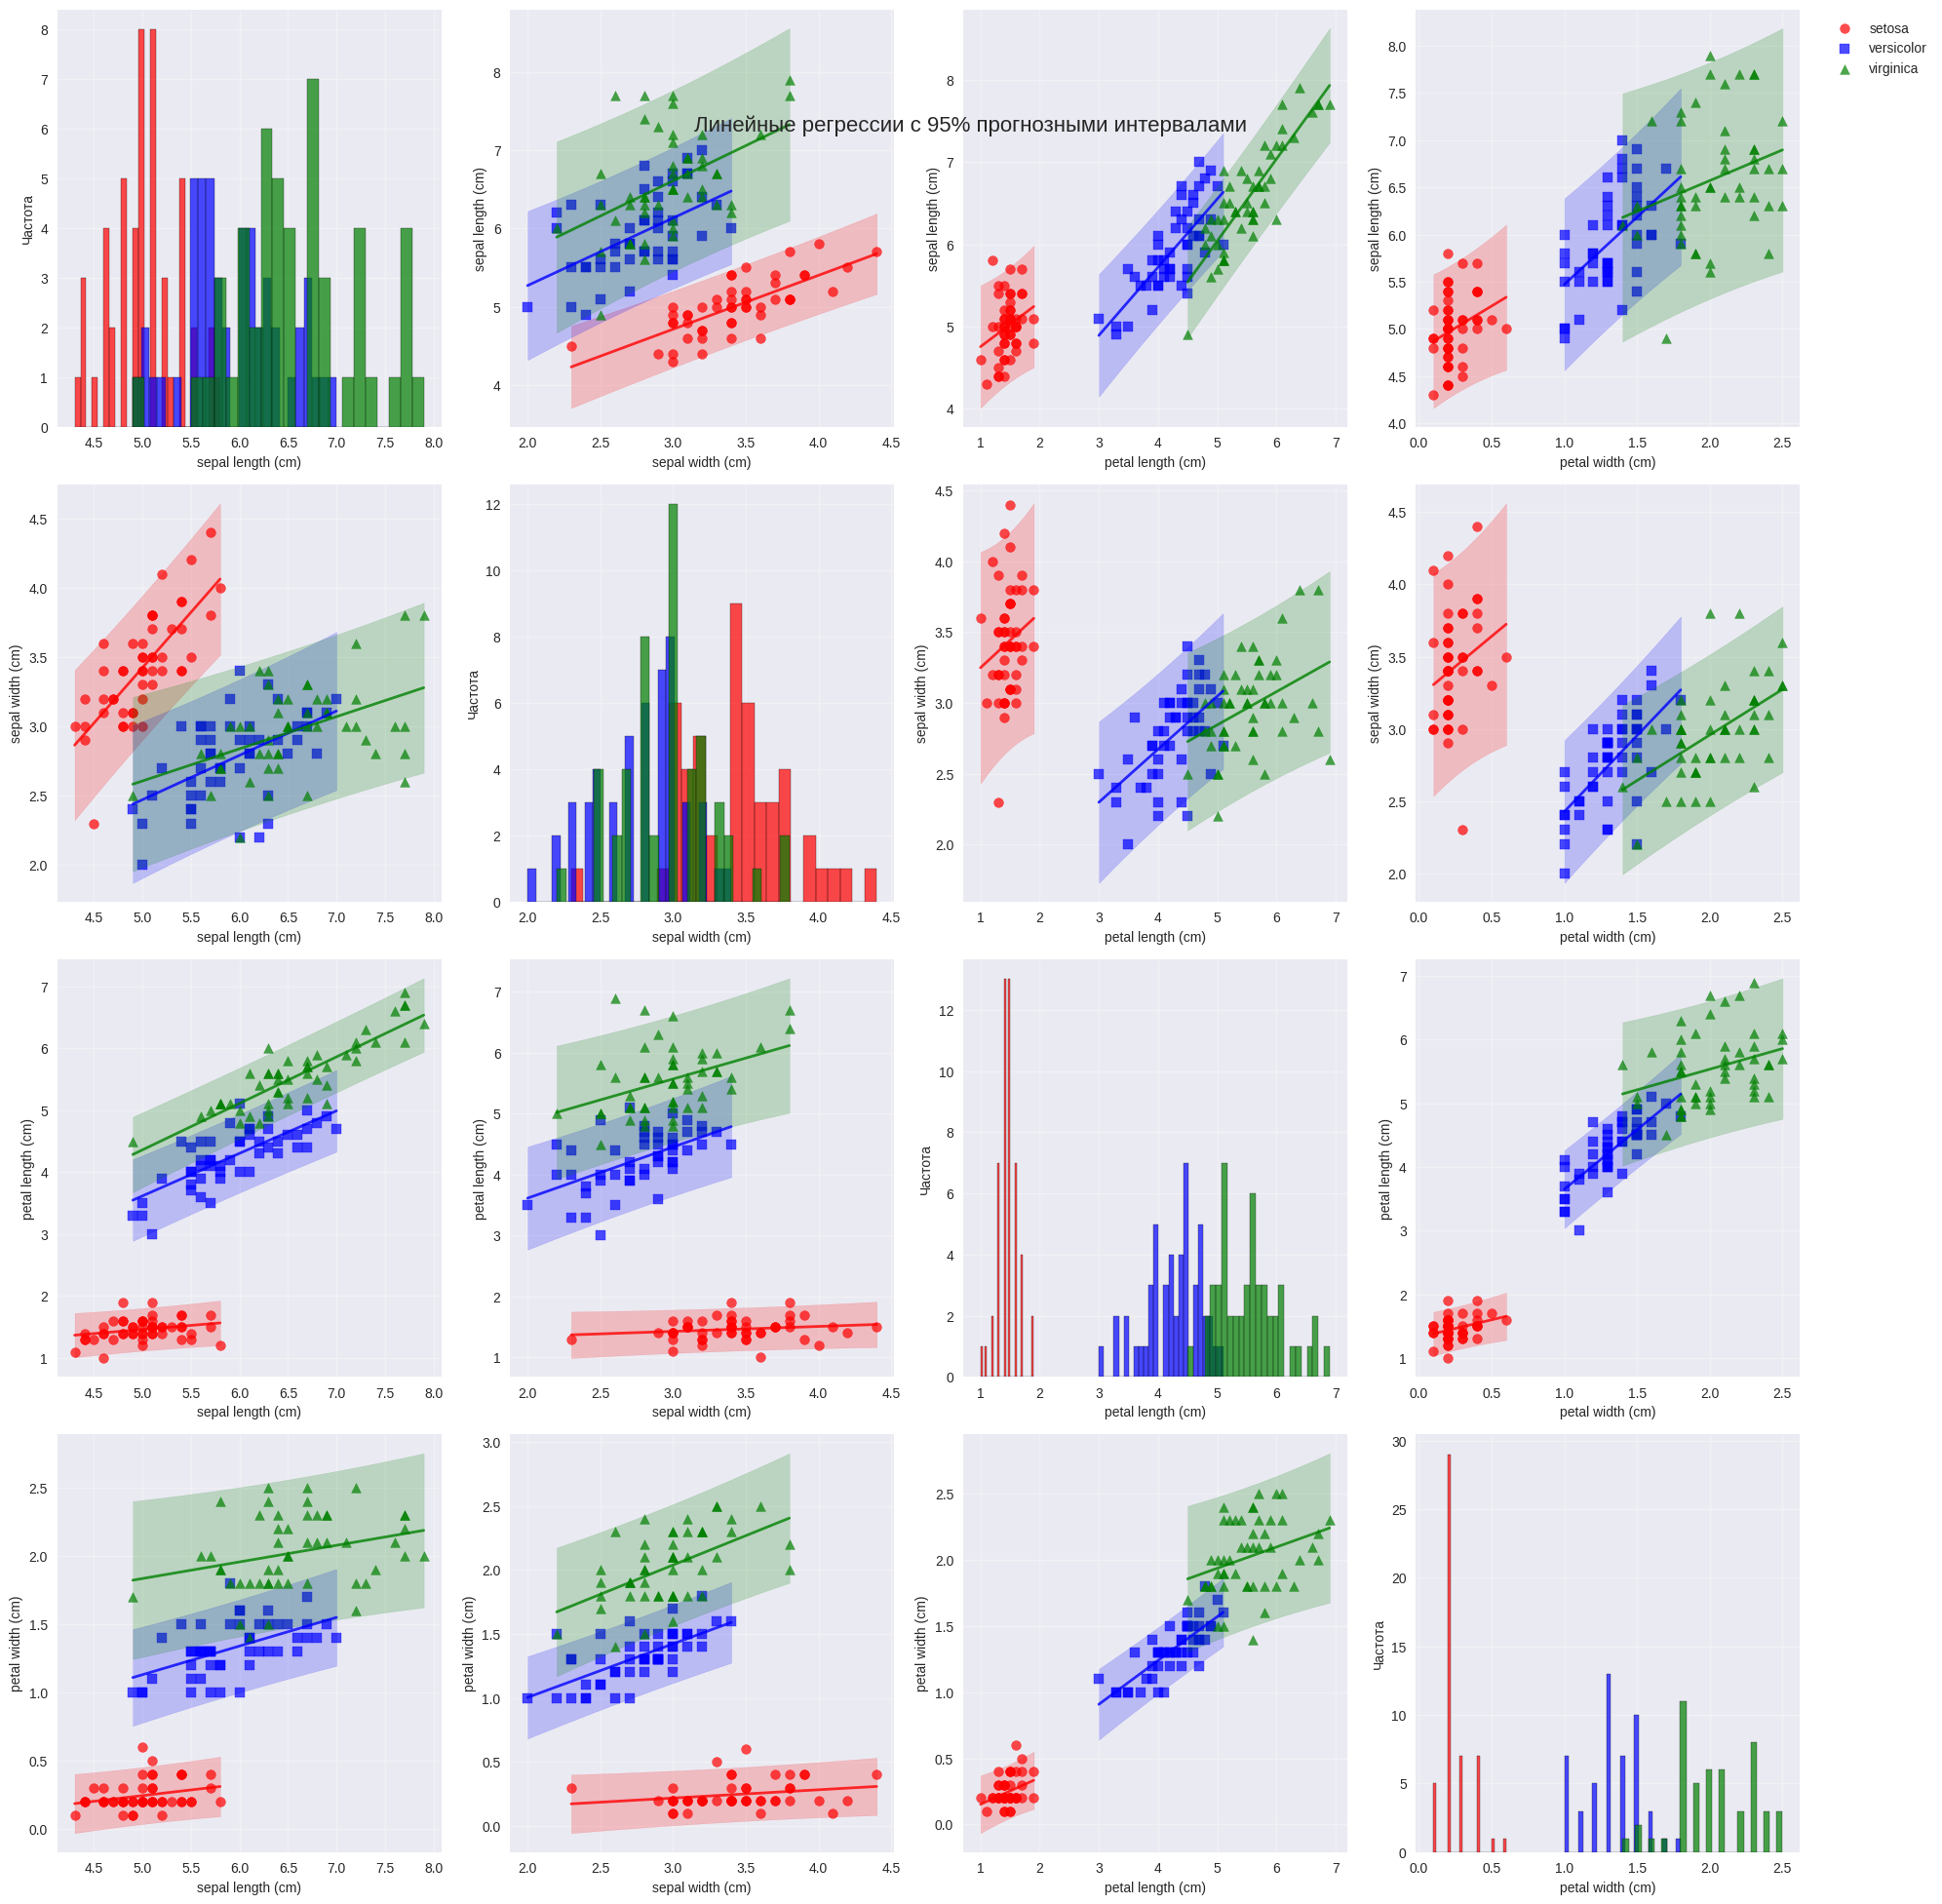

РЕГРЕССИЯ С ДОВЕРИТЕЛЬНЫМИ ИНТЕРВАЛАМИ


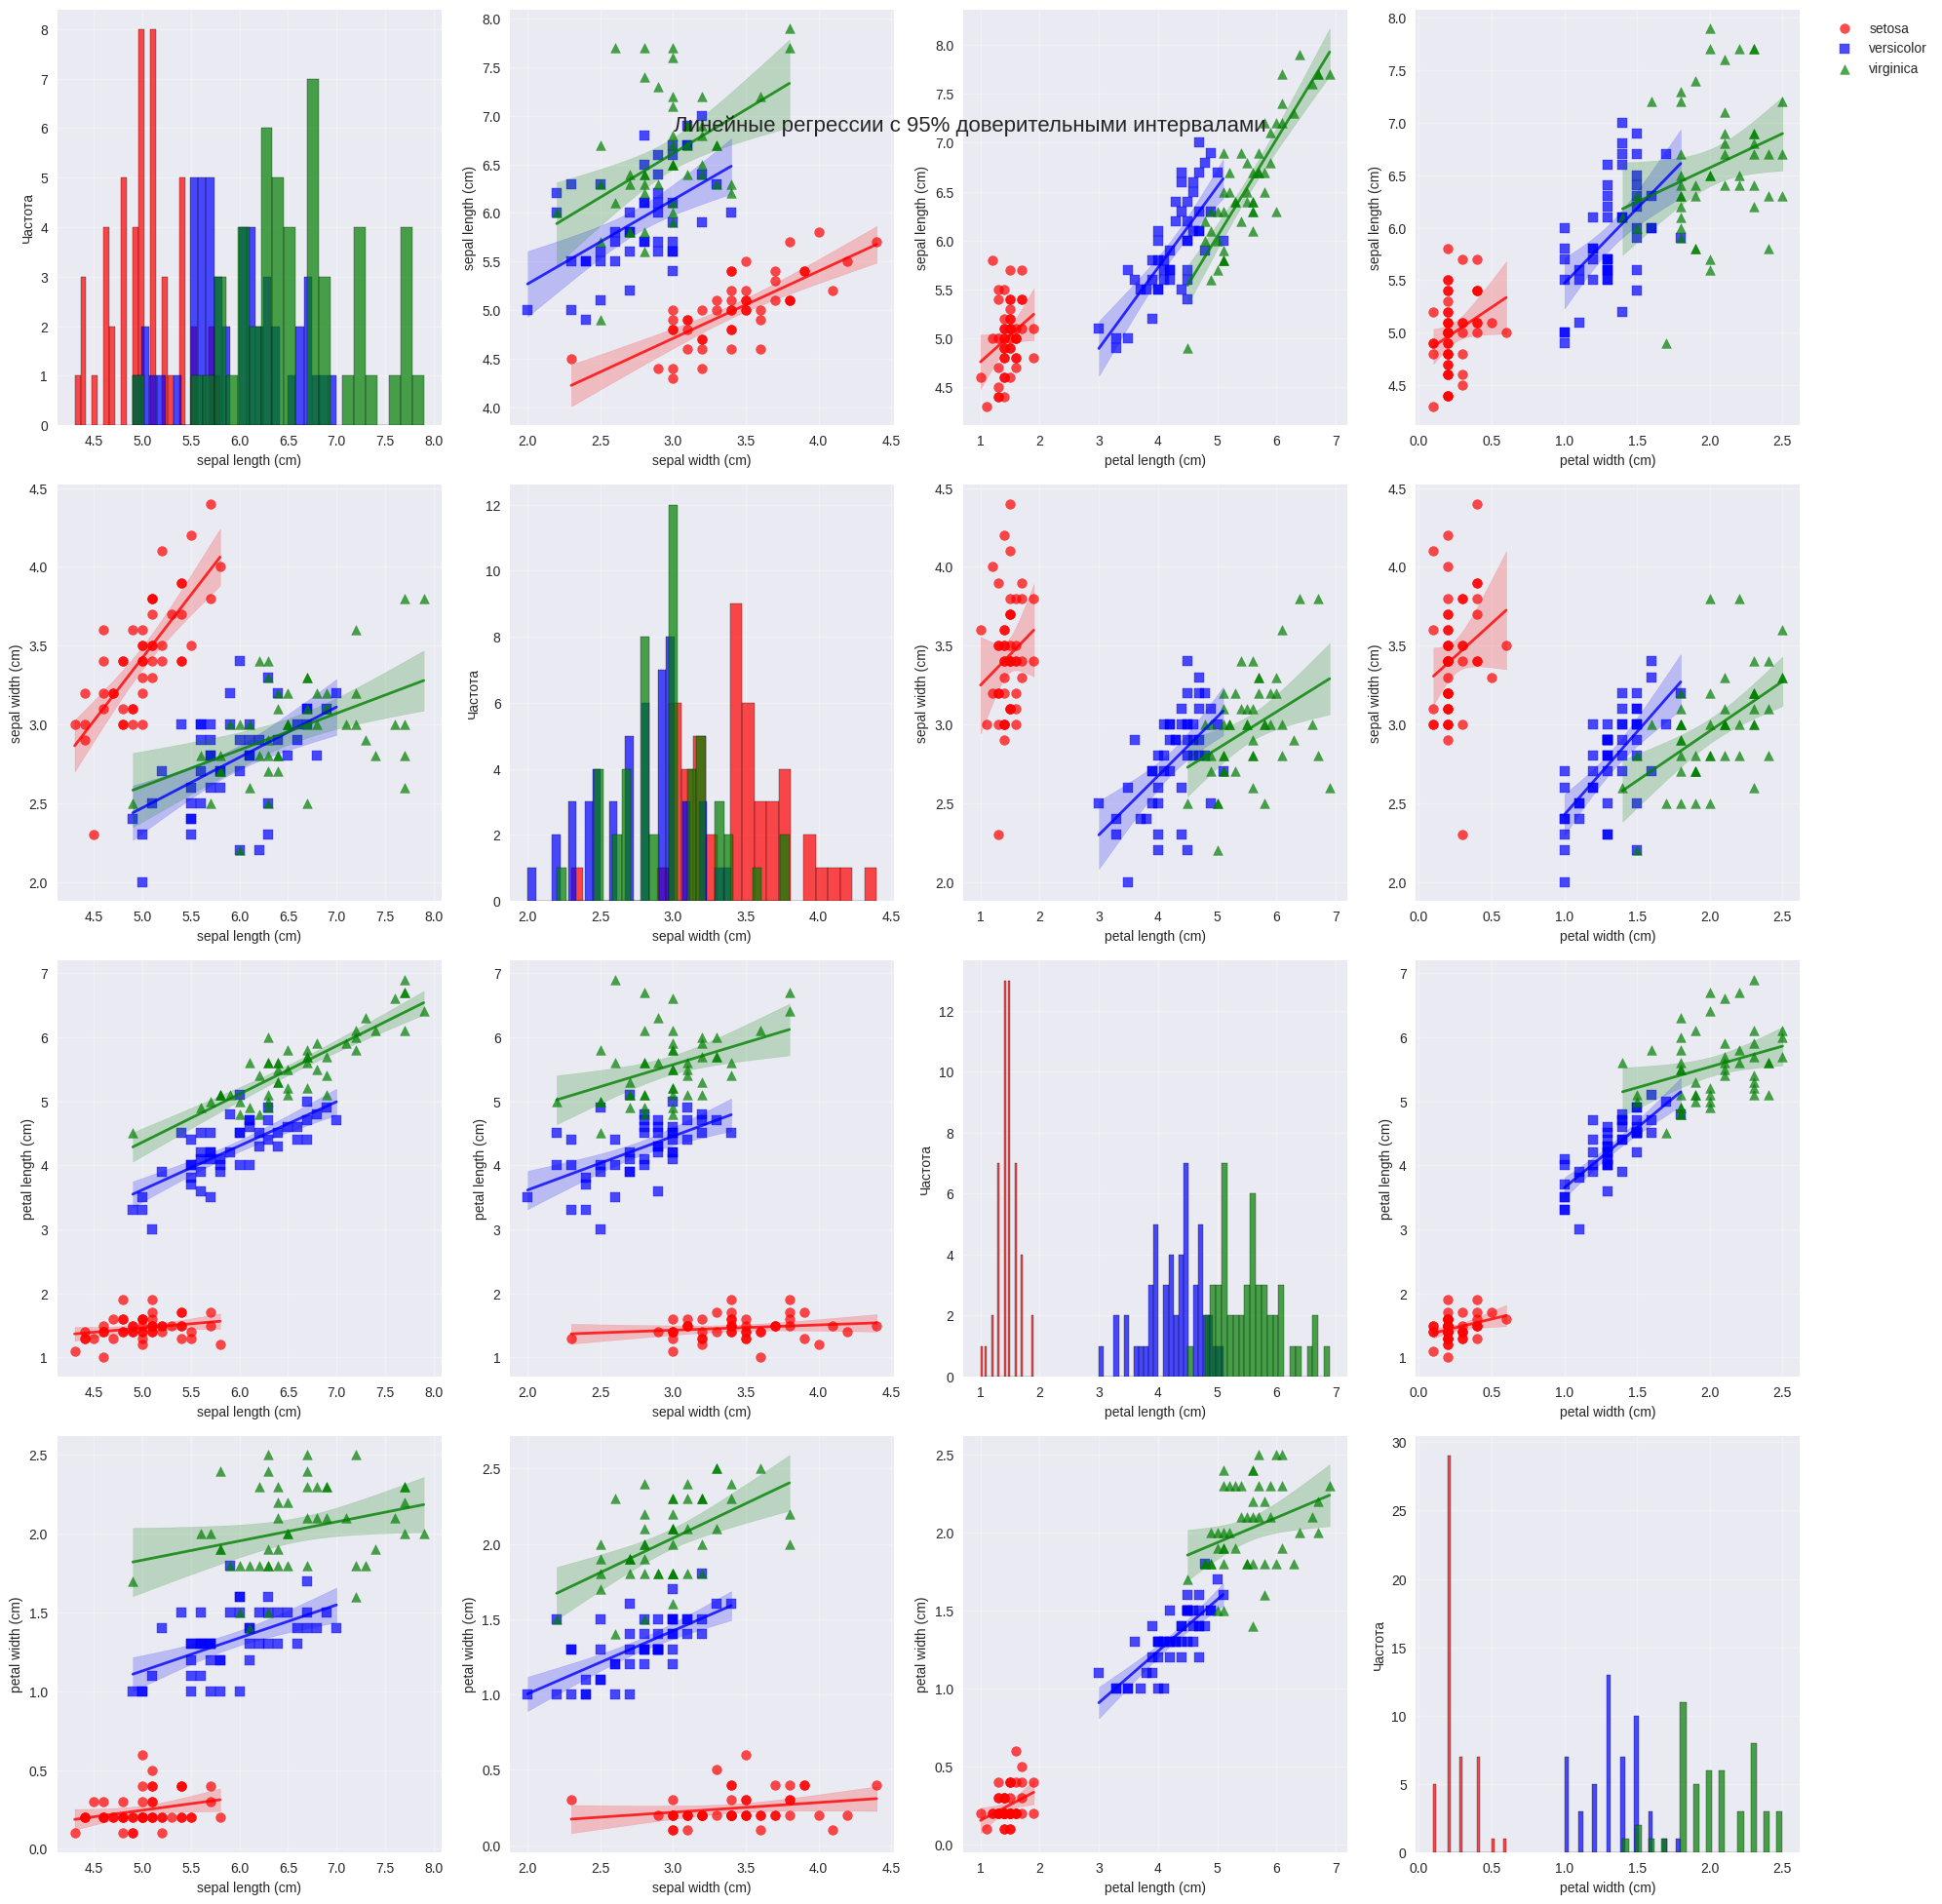

In [29]:
def plot_regression_with_intervals(x, y, data, ax, interval_type='prediction', color='blue'):
    """Построение регрессии с интервалами"""
    X = data[x].values.reshape(-1, 1)
    y_values = data[y].values
    
    model = LinearRegression()
    model.fit(X, y_values)
    
    # Прогнозы
    x_range = np.linspace(X.min(), X.max(), 100)
    y_pred = model.predict(x_range.reshape(-1, 1))
    
    # Расчет стандартных ошибок
    n = len(X)
    x_mean = np.mean(X)
    s_xx = np.sum((X - x_mean)**2)
    residuals = y_values - model.predict(X)
    mse = np.sum(residuals**2) / (n - 2)
    
    if interval_type == 'prediction':
        # Прогнозные интервалы
        se = np.sqrt(mse * (1 + 1/n + (x_range - x_mean)**2 / s_xx))
    else:
        # Доверительные интервалы
        se = np.sqrt(mse * (1/n + (x_range - x_mean)**2 / s_xx))
    
    t_val = stats.t.ppf(0.975, n - 2)  # 95% интервал
    
    # Построение графиков
    ax.plot(x_range, y_pred, color=color, linewidth=2, alpha=0.8)
    ax.fill_between(x_range, y_pred - t_val * se, y_pred + t_val * se, 
                   alpha=0.2, color=color)
    
    return model, x_range, y_pred, se

def create_regression_plots(df, features, interval_type='prediction'):
    """Создание графиков с регрессиями"""
    class_colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}
    class_markers = {'setosa': 'o', 'versicolor': 's', 'virginica': '^'}
    
    title_suffix = 'прогнозными' if interval_type == 'prediction' else 'доверительными'
    
    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    fig.suptitle(f'Линейные регрессии с 95% {title_suffix} интервалами', 
                fontsize=16, y=0.92)
    
    regression_results = []
    
    for i, feat1 in enumerate(features):
        for j, feat2 in enumerate(features):
            ax = axes[i, j]
            
            if i != j:
                for class_name in classes:
                    class_data = df[df['species'] == class_name]
                    
                    # Точечный график
                    ax.scatter(class_data[feat2], class_data[feat1], 
                              marker=class_markers[class_name], 
                              color=class_colors[class_name],
                              alpha=0.7, label=class_name, s=50)
                    
                    # Регрессия с интервалами
                    model, x_range, y_pred, se = plot_regression_with_intervals(
                        feat2, feat1, class_data, ax, interval_type, class_colors[class_name])
                    
                    # Сохранение результатов регрессии
                    regression_results.append({
                        'X': feat2, 'Y': feat1, 'Class': class_name,
                        'Slope': model.coef_[0], 'Intercept': model.intercept_,
                        'R2': model.score(class_data[feat2].values.reshape(-1, 1), 
                                        class_data[feat1].values)
                    })
                
                ax.set_xlabel(feat2, fontsize=10)
                ax.set_ylabel(feat1, fontsize=10)
                ax.grid(True, alpha=0.3)
                
                if i == 0 and j == len(features)-1:
                    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            else:
                # Гистограмма на диагонали
                for class_name in classes:
                    class_data = df[df['species'] == class_name]
                    ax.hist(class_data[feat1], bins=25, alpha=0.7, 
                           label=class_name, color=class_colors[class_name],
                           edgecolor='black')
                
                ax.set_xlabel(feat1, fontsize=10)
                ax.set_ylabel('Частота', fontsize=10)
                ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'regression_{interval_type}_intervals.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return pd.DataFrame(regression_results)

# Построение графиков с прогнозными интервалами
print("РЕГРЕССИЯ С ПРОГНОЗНЫМИ ИНТЕРВАЛАМИ")
results_pred = create_regression_plots(df, features, 'prediction')

# Построение графиков с доверительными интервалами
print("РЕГРЕССИЯ С ДОВЕРИТЕЛЬНЫМИ ИНТЕРВАЛАМИ")
results_conf = create_regression_plots(df, features, 'confidence')


[7] СТАТИСТИКИ РЕГРЕССИИ

In [30]:
def calculate_regression_statistics(df, features):
    """Расчет расширенной статистики для регрессий"""
    results = []
    
    for class_name in classes:
        class_data = df[df['species'] == class_name]
        
        for i, feat1 in enumerate(features):
            for j, feat2 in enumerate(features):
                if i != j:
                    # Подготовка данных
                    X = class_data[feat2].values.reshape(-1, 1)
                    y = class_data[feat1].values
                    
                    # Линейная регрессия
                    model = LinearRegression()
                    model.fit(X, y)
                    y_pred = model.predict(X)
                    
                    # Основные статистики
                    n = len(X)
                    r2 = model.score(X, y)
                    
                    # F-статистика (критерий Вальда)
                    ssr = np.sum((y_pred - np.mean(y))**2)
                    sse = np.sum((y - y_pred)**2)
                    msr = ssr / 1
                    mse = sse / (n - 2)
                    f_stat = msr / mse
                    f_p_value = 1 - stats.f.cdf(f_stat, 1, n - 2)
                    
                    # LR тест (хи-квадрат)
                    lr_stat = -2 * (np.log(sse) - np.log(np.sum((y - np.mean(y))**2)))
                    lr_p_value = 1 - stats.chi2.cdf(lr_stat, 1)
                    
                    # Score test
                    score_stat = n * r2
                    score_p_value = 1 - stats.chi2.cdf(score_stat, 1)
                    
                    results.append({
                        'Класс': class_name,
                        'Зависимая переменная': feat1,
                        'Независимая переменная': feat2,
                        'Формула': f'{feat1} = {model.intercept_:.3f} + {model.coef_[0]:.3f}×{feat2}',
                        'R²': r2,
                        'F-статистика': f_stat,
                        'F p-value': f_p_value,
                        'LR χ²': lr_stat,
                        'LR p-value': lr_p_value,
                        'Score χ²': score_stat,
                        'Score p-value': score_p_value
                    })
    
    return pd.DataFrame(results)

print("СТАТИСТИКИ ЛИНЕЙНЫХ РЕГРЕССИЙ")
print("=" * 60)
regression_stats = calculate_regression_statistics(df, features)

# Вывод результатов в виде таблицы
print(regression_stats.to_string(index=False))

# Сохранение результатов
regression_stats.to_csv('regression_statistics.csv', index=False, encoding='utf-8-sig')

СТАТИСТИКИ ЛИНЕЙНЫХ РЕГРЕССИЙ
     Класс Зависимая переменная Независимая переменная                                             Формула       R²  F-статистика    F p-value    LR χ²  LR p-value  Score χ²  Score p-value
    setosa    sepal length (cm)       sepal width (cm)  sepal length (cm) = 2.639 + 0.690×sepal width (cm) 0.551376     58.993730 6.709843e-10 1.603138    0.205459 27.568779   1.516062e-07
    setosa    sepal length (cm)      petal length (cm) sepal length (cm) = 4.213 + 0.542×petal length (cm) 0.071383      3.689765 6.069778e-02 0.148118    0.700341  3.569144   5.886264e-02
    setosa    sepal length (cm)       petal width (cm)  sepal length (cm) = 4.777 + 0.930×petal width (cm) 0.077339      4.023424 5.052644e-02 0.160986    0.688250  3.866935   4.924639e-02
    setosa     sepal width (cm)      sepal length (cm) sepal width (cm) = -0.569 + 0.799×sepal length (cm) 0.551376     58.993730 6.709843e-10 1.603138    0.205459 27.568779   1.516062e-07
    setosa     sepal widt

[8-9] ДИСПЕРСИОННЫЙ АНАЛИЗ (ANOVA)


ДИСПЕРСИОННЫЙ АНАЛИЗ ДЛЯ ПРИЗНАКА: sepal length (cm)
F-критерий: F(2, 147) = 119.2645
P-value: 0.0000

Попарные сравнения (Tukey HSD):
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor     0.93   0.0 0.6862 1.1738   True
    setosa  virginica    1.582   0.0 1.3382 1.8258   True
versicolor  virginica    0.652   0.0 0.4082 0.8958   True
---------------------------------------------------------


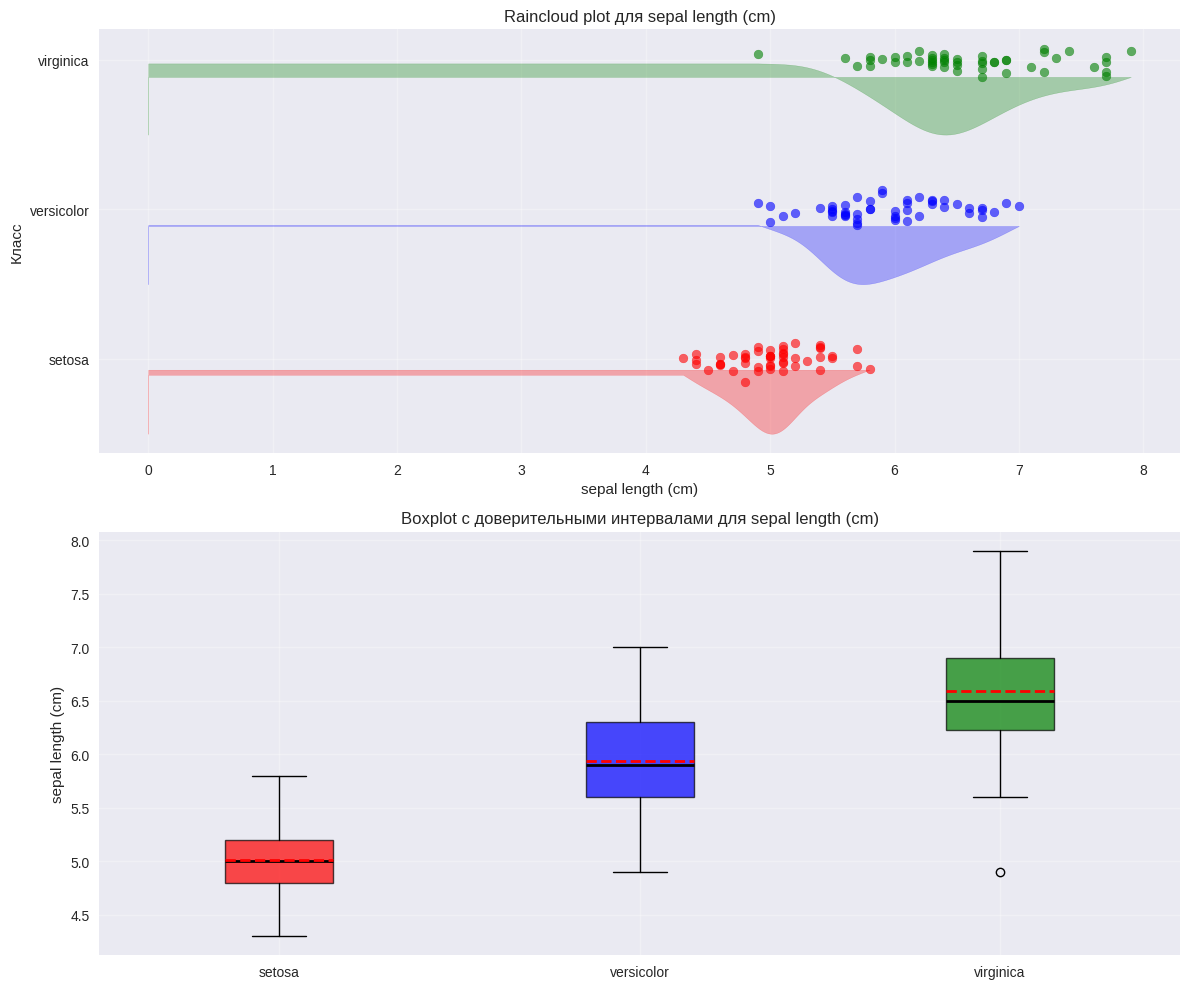


ДИСПЕРСИОННЫЙ АНАЛИЗ ДЛЯ ПРИЗНАКА: sepal width (cm)
F-критерий: F(2, 147) = 49.1600
P-value: 0.0000

Попарные сравнения (Tukey HSD):
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower   upper  reject
------------------------------------------------------------
    setosa versicolor   -0.658    0.0 -0.8189 -0.4971   True
    setosa  virginica   -0.454    0.0 -0.6149 -0.2931   True
versicolor  virginica    0.204 0.0088  0.0431  0.3649   True
------------------------------------------------------------


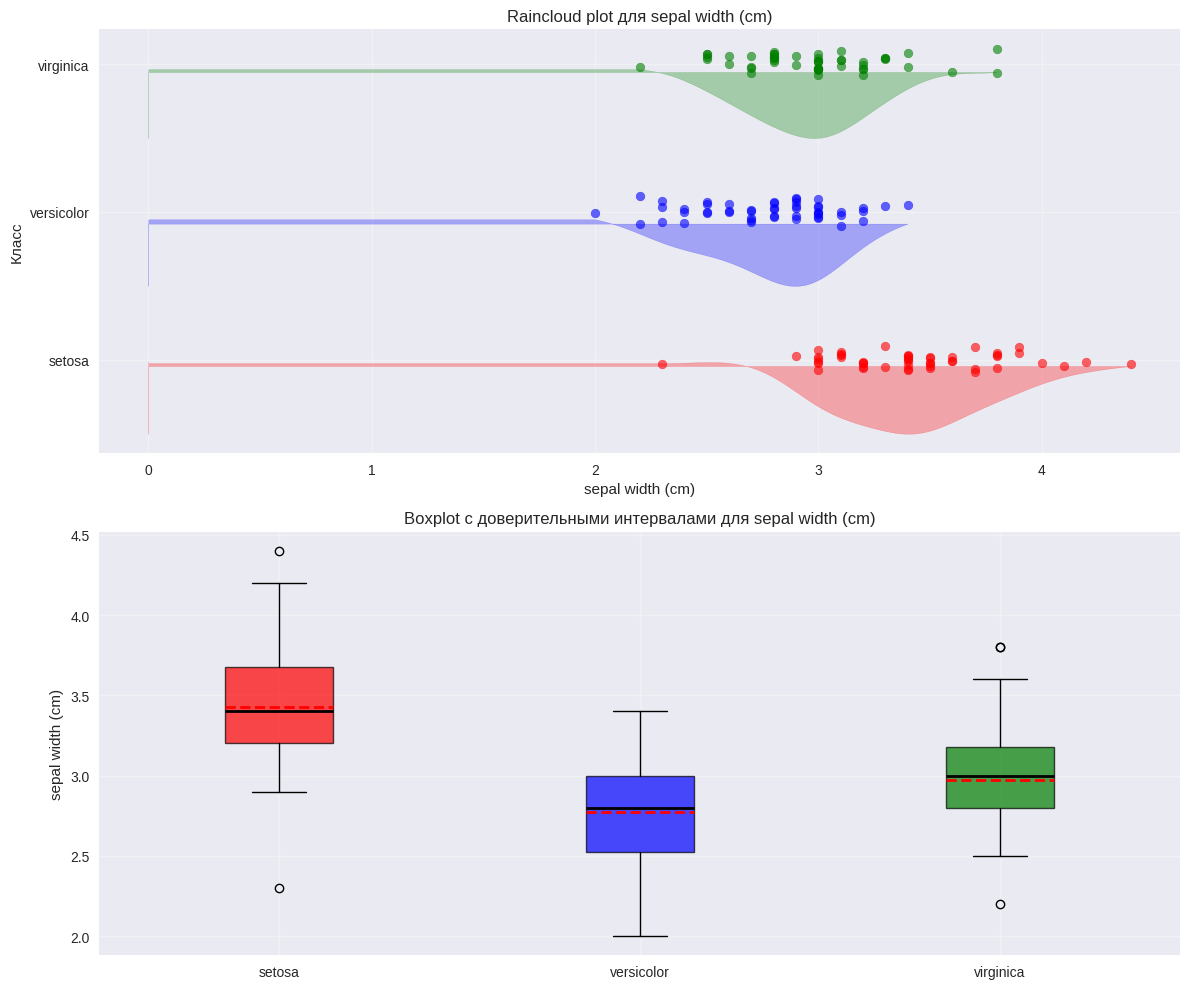


ДИСПЕРСИОННЫЙ АНАЛИЗ ДЛЯ ПРИЗНАКА: petal length (cm)
F-критерий: F(2, 147) = 1180.1612
P-value: 0.0000

Попарные сравнения (Tukey HSD):
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor    2.798   0.0 2.5942 3.0018   True
    setosa  virginica     4.09   0.0 3.8862 4.2938   True
versicolor  virginica    1.292   0.0 1.0882 1.4958   True
---------------------------------------------------------


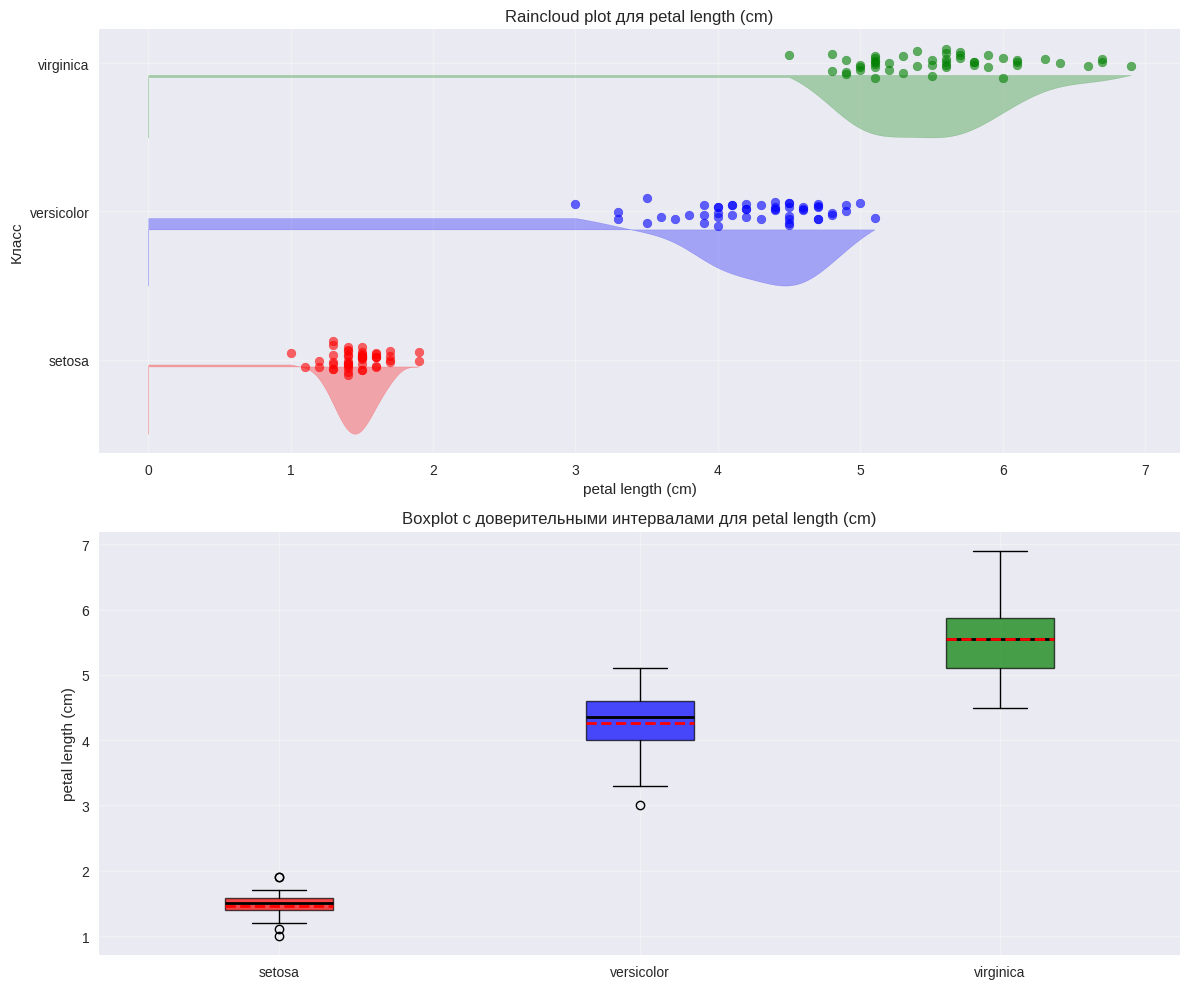


ДИСПЕРСИОННЫЙ АНАЛИЗ ДЛЯ ПРИЗНАКА: petal width (cm)
F-критерий: F(2, 147) = 960.0071
P-value: 0.0000

Попарные сравнения (Tukey HSD):
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor     1.08   0.0 0.9831 1.1769   True
    setosa  virginica     1.78   0.0 1.6831 1.8769   True
versicolor  virginica      0.7   0.0 0.6031 0.7969   True
---------------------------------------------------------


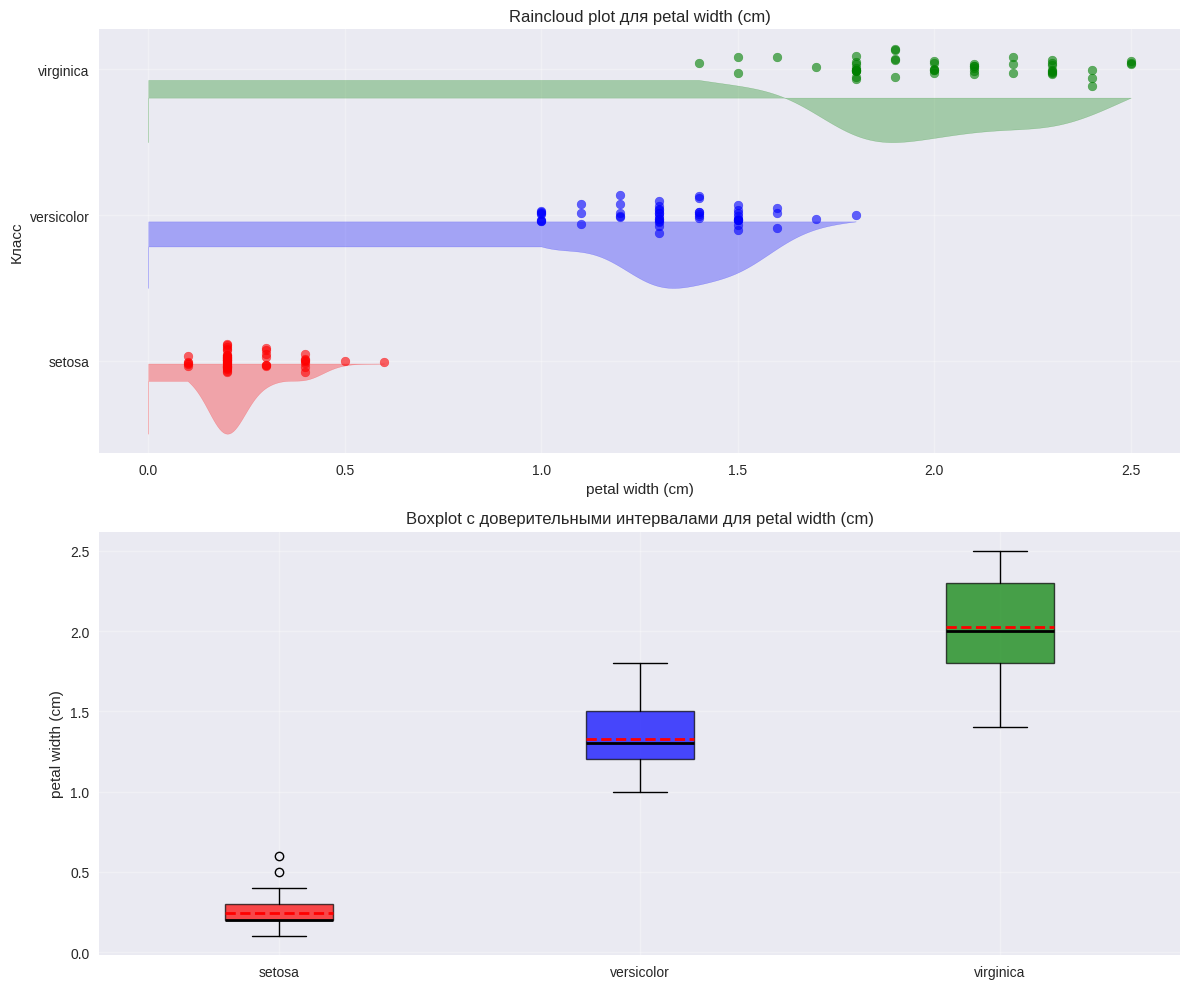


СВОДНАЯ ТАБЛИЦА ANOVA ДЛЯ ВСЕХ ПРИЗНАКОВ
          Признак  F-статистика      P-value  Степени свободы (межгрупповые)  Степени свободы (внутригрупповые)
sepal length (cm)    119.264502 1.669669e-31                               2                                147
 sepal width (cm)     49.160040 4.492017e-17                               2                                147
petal length (cm)   1180.161182 2.856777e-91                               2                                147
 petal width (cm)    960.007147 4.169446e-85                               2                                147


In [31]:
def perform_anova_analysis(df, feature, classes):
    """Выполнение дисперсионного анализа для одного признака"""
    print(f"\nДИСПЕРСИОННЫЙ АНАЛИЗ ДЛЯ ПРИЗНАКА: {feature}")
    print("=" * 50)
    
    # Подготовка данных
    data_groups = [df[df['species'] == cls][feature] for cls in classes]
    
    # Односторонний ANOVA
    f_stat, p_value = stats.f_oneway(*data_groups)
    
    # Степени свободы
    df_between = len(classes) - 1
    df_within = len(df) - len(classes)
    
    print(f"F-критерий: F({df_between}, {df_within}) = {f_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    # Попарные сравнения (Tukey HSD)
    print("\nПопарные сравнения (Tukey HSD):")
    tukey = pairwise_tukeyhsd(df[feature], df['species'], alpha=0.05)
    print(tukey.summary())
    
    return f_stat, p_value, tukey

def create_raincloud_plot(df, feature, classes):
    """Создание raincloud plot с jittering и boxplot"""
    class_colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Raincloud plot
    for i, class_name in enumerate(classes):
        class_data = df[df['species'] == class_name][feature]
        
        # Jittered points
        y_jitter = np.random.normal(i, 0.05, len(class_data))
        ax1.scatter(class_data, y_jitter, alpha=0.6, color=class_colors[class_name], s=40)
        
        # Density plot (облако)
        kde = gaussian_kde(class_data)
        x_range = np.linspace(class_data.min(), class_data.max(), 100)
        density = kde(x_range)
        ax1.fill_betweenx(-density/density.max()/2 + i, x_range, 
                         alpha=0.3, color=class_colors[class_name])
    
    ax1.set_yticks(range(len(classes)))
    ax1.set_yticklabels(classes)
    ax1.set_xlabel(feature)
    ax1.set_ylabel('Класс')
    ax1.set_title(f'Raincloud plot для {feature}')
    ax1.grid(True, alpha=0.3)
    
    # Boxplot с доверительными интервалами
    box_data = [df[df['species'] == cls][feature] for cls in classes]
    bp = ax2.boxplot(box_data, labels=classes, patch_artist=True, 
                    showmeans=True, meanline=True)
    
    # Раскрашиваем boxplot
    for patch, color in zip(bp['boxes'], [class_colors[cls] for cls in classes]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Настройка внешнего вида
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)
    
    for mean in bp['means']:
        mean.set_color('red')
        mean.set_linewidth(2)
    
    ax2.set_ylabel(feature)
    ax2.set_title(f'Boxplot с доверительными интервалами для {feature}')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'anova_{feature.replace(" ", "_").replace("(", "").replace(")", "")}.png', 
                dpi=300, bbox_inches='tight')
    plt.show()

# ANOVA для всех признаков
anova_results = []
for feature in features:
    f_stat, p_value, tukey = perform_anova_analysis(df, feature, classes)
    create_raincloud_plot(df, feature, classes)
    
    anova_results.append({
        'Признак': feature,
        'F-статистика': f_stat,
        'P-value': p_value,
        'Степени свободы (межгрупповые)': len(classes) - 1,
        'Степени свободы (внутригрупповые)': len(df) - len(classes)
    })

# Сводная таблица ANOVA
anova_summary = pd.DataFrame(anova_results)
print("\nСВОДНАЯ ТАБЛИЦА ANOVA ДЛЯ ВСЕХ ПРИЗНАКОВ")
print("=" * 60)
print(anova_summary.to_string(index=False))


СОХРАНЕНИЕ РЕЗУЛЬТАТОВ

In [32]:
# Сохранение основных результатов
with open('lab_results_summary.txt', 'w', encoding='utf-8') as f:
    f.write("РЕЗУЛЬТАТЫ ЛАБОРАТОРНОЙ РАБОТЫ\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Датасет: Iris\n")
    f.write(f"Размерность: {df.shape}\n")
    f.write(f"Признаки: {', '.join(features)}\n")
    f.write(f"Классы: {', '.join(classes)}\n\n")
    
    f.write("АНАЛИЗ ANOVA:\n")
    for result in anova_results:
        f.write(f"{result['Признак']}: F = {result['F-статистика']:.4f}, p = {result['P-value']:.4f}\n")

print("Все результаты сохранены в файлы:")
print("- pair_plots.png")
print("- regression_prediction_intervals.png") 
print("- regression_confidence_intervals.png")
print("- regression_statistics.csv")
print("- anova_*.png (для каждого признака)")
print("- lab_results_summary.txt")

# %%
# ФИНАЛЬНАЯ СВОДКА
print("\n" + "="*60)
print("ФИНАЛЬНАЯ СВОДКА РЕЗУЛЬТАТОВ")
print("="*60)

print(f"✓ Проанализировано признаков: {len(features)}")
print(f"✓ Построено регрессионных моделей: {len(regression_stats)}")
print(f"✓ Выполнено ANOVA тестов: {len(anova_results)}")
print(f"✓ Создано визуализаций: {4 + len(features)}")

# Проверка значимости ANOVA
significant_features = [res['Признак'] for res in anova_results if res['P-value'] < 0.05]
print(f"✓ Статистически значимые различия между классами найдены для {len(significant_features)} признаков:")
for feat in significant_features:
    print(f"  - {feat}")

Все результаты сохранены в файлы:
- pair_plots.png
- regression_prediction_intervals.png
- regression_confidence_intervals.png
- regression_statistics.csv
- anova_*.png (для каждого признака)
- lab_results_summary.txt

ФИНАЛЬНАЯ СВОДКА РЕЗУЛЬТАТОВ
✓ Проанализировано признаков: 4
✓ Построено регрессионных моделей: 36
✓ Выполнено ANOVA тестов: 4
✓ Создано визуализаций: 8
✓ Статистически значимые различия между классами найдены для 4 признаков:
  - sepal length (cm)
  - sepal width (cm)
  - petal length (cm)
  - petal width (cm)
